In [ ]:
import pandas as pd

Procedemos a la carga de los datos ya tratado para el challege

In [ ]:
datos=pd.read_csv('/content/datos_challege_parte_2_telecomx.csv')
print(datos.head())
print(datos.info())

   CustomerID Churn  Gender SeniorCitizen Partner Dependents  Tenure  \
0  0002-ORFBO    No  Female            No     Yes        Yes       9   
1  0003-MKNFE    No    Male            No      No         No       9   
2  0004-TLHLJ   Yes    Male            No      No         No       4   
3  0011-IGKFF   Yes    Male           Yes     Yes         No      13   
4  0013-EXCHZ   Yes  Female           Yes     Yes         No       3   

  PhoneService MultipleLines InternetService  ... DeviceProtection  \
0          Yes            No             DSL  ...               No   
1          Yes           Yes             DSL  ...               No   
2          Yes            No     Fiber optic  ...              Yes   
3          Yes            No     Fiber optic  ...              Yes   
4          Yes            No     Fiber optic  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract PaperlessBilling  \
0         Yes         Yes              No        One year           

--- Proporción de Clases ---
Churn
0    73.46%
1    26.54%
Name: proportion, dtype: object
----------------------------


/tmp/ipython-input-3600363619.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='Tenure', data=df, ax=axes[0], palette='coolwarm')
/tmp/ipython-input-3600363619.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Retenido (0)', 'Fuga (1)'])
/tmp/ipython-input-3600363619.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='ChargesTotal', data=df, ax=axes[1], palette='coolwarm')
/tmp/ipython-input-3600363619.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].se

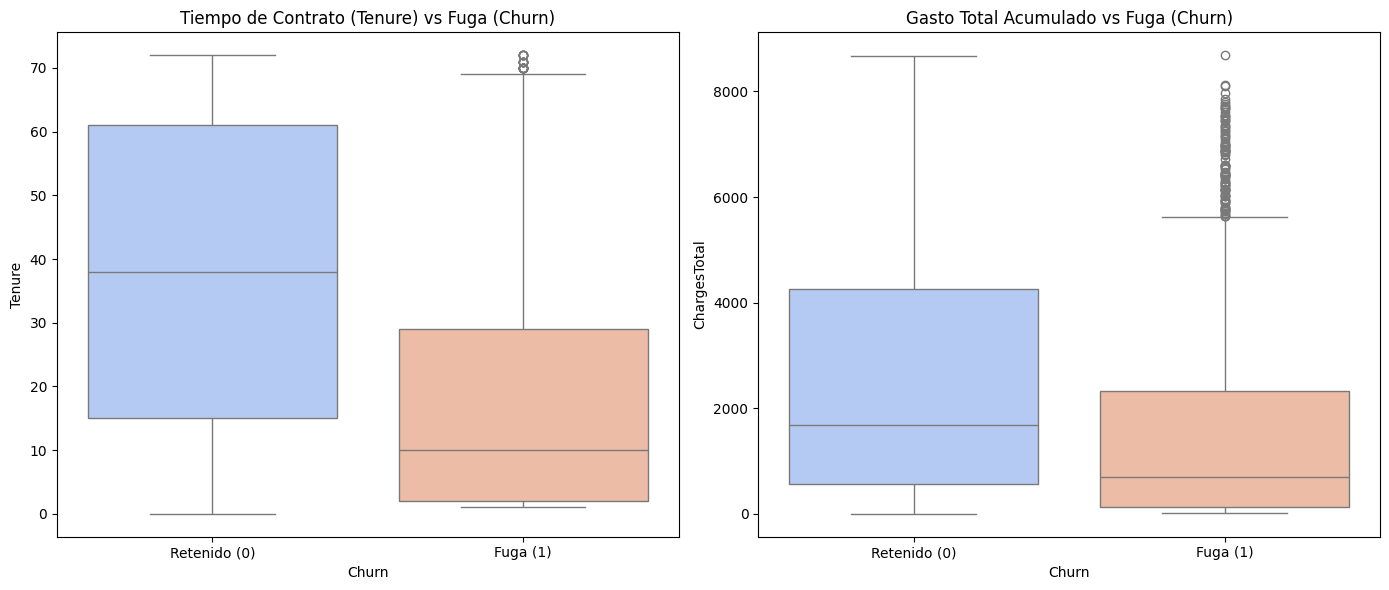

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def load_and_prepare_data(filepath: str) -> pd.DataFrame:
    """
  Carga el dataset eliminandp identificadores y transforma la variable objetivo
    """
    df = pd.read_csv(filepath)

    #Elimino identificadores que no aportan valor predictivo
    if 'CustomerID' in df.columns:
        df = df.drop(columns=['CustomerID'])

    #Transformo el Target a numerico
    df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

    return df

def analyze_class_balance(df: pd.DataFrame, target_col: str = 'Churn'):
    """
    Imprime la proporcion de la variable objetivo para detectar desbalance
    """
    proportions = df[target_col].value_counts(normalize=True) * 100
    print("proporción de Clases ")
    print(proportions.round(2).astype(str) + '%')
    print("-" * 28)

def plot_targeted_eda(df: pd.DataFrame):
    """
    Genera visualizaciones para entender la relacion entre variables clave y Churn.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    #Boxplot:Tenure vs Churn
    sns.boxplot(x='Churn', y='Tenure', data=df, ax=axes[0], palette='coolwarm')
    axes[0].set_title('Tiempo de Contrato (Tenure) vs Fuga (Churn)')
    axes[0].set_xticklabels(['Retenido (0)', 'Fuga (1)'])

    #Boxplot:ChargesTotal vs Churn
    sns.boxplot(x='Churn', y='ChargesTotal', data=df, ax=axes[1], palette='coolwarm')
    axes[1].set_title('Gasto Total Acumulado vs Fuga (Churn)')
    axes[1].set_xticklabels(['Retenido (0)', 'Fuga (1)'])
    plt.tight_layout()
    plt.show()

# EJECUCION DEL PIPELINE INICIAL
filepath = '/content/datos_challege_parte_2_telecomx.csv' # Cambia la ruta si es necesario
df_telecom = load_and_prepare_data(filepath)
analyze_class_balance(df_telecom)
plot_targeted_eda(df_telecom)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
def split_and_prepare_pipelines(df: pd.DataFrame, target_col: str = 'Churn'):
    """
    Separa los datos y crea pipelines de preprocesamiento para evitar Data Leakage
    """
    #1-Separar Features (X) y Target (y)
    X = df.drop(columns=[target_col])
    y = df[target_col]

    #2-Split Estratificado (Mantiene la proporción 73/27 en train y test)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    print(f"Tamaño de Entrenamiento: {X_train.shape[0]} filas")
    print(f"Tamaño de Prueba: {X_test.shape[0]} filas")

    #3-Identificar variables numéricas y categóricas
    #(Tenure, ChargesDaily, ChargesMonthly, ChargesTotal son numéricas)
    numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
    categorical_features = X.select_dtypes(include=['object']).columns.tolist()

    #4-Pipeline para Modelos de Distancia (Estandarización + OHE)
    #drop='first' evita la multicolinealidad en regresiones lineales/logIsticas
    preprocessor_distance = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), numeric_features),
            ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
        ])

    #5-Pipeline para Modelos de Árboles (Passthrough + OHE)
    preprocessor_trees = ColumnTransformer(
        transformers=[
            ('num', 'passthrough', numeric_features),
            ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
        ])

    return X_train, X_test, y_train, y_test, preprocessor_distance, preprocessor_trees

#EJECUCIÓN DEL PASO 4
X_train, X_test, y_train, y_test, prep_dist, prep_trees = split_and_prepare_pipelines(df_telecom)

Tamaño de Entrenamiento: 5634 filas
Tamaño de Prueba: 1409 filas



=== Reporte: Logit (Distancia) ===
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1035
           1       0.64      0.52      0.57       374

    accuracy                           0.79      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.78      0.79      0.79      1409



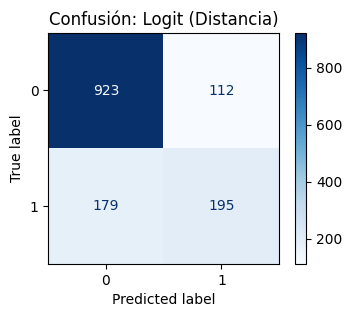


=== Reporte: Random Forest (Árboles) ===
              precision    recall  f1-score   support

           0       0.82      0.89      0.86      1035
           1       0.61      0.47      0.53       374

    accuracy                           0.78      1409
   macro avg       0.72      0.68      0.69      1409
weighted avg       0.77      0.78      0.77      1409



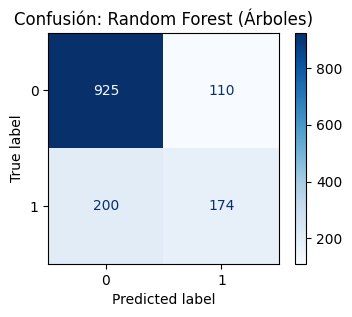

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

def train_and_evaluate(X_train, X_test, y_train, y_test, prep_dist, prep_trees):
    #DefinO los modelos
    models = {
        "Logit (Distancia)": Pipeline(steps=[
            ('preprocessor', prep_dist),
            ('classifier', LogisticRegression(max_iter=1000, random_state=42))
        ]),
        "Random Forest (Árboles)": Pipeline(steps=[
            ('preprocessor', prep_trees),
            ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
        ])
    }

    results = {}

    #Entrenar y Evaluar
    for name, pipeline in models.items():
        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)

        print(f"\n=== Reporte: {name} ===")
        print(classification_report(y_test, y_pred))
        results[name] = pipeline

        # Visualizar Matriz de Confusión
        fig, ax = plt.subplots(figsize=(4, 3))
        ConfusionMatrixDisplay.from_estimator(pipeline, X_test, y_test, ax=ax, cmap='Blues')
        ax.set_title(f"Confusión: {name}")
        plt.show()

    return results

#EJECUCION DEL PASO 5
modelos_entrenados = train_and_evaluate(X_train, X_test, y_train, y_test, prep_dist, prep_trees)

In [ ]:
import numpy as np

def get_feature_importance_logit(pipeline, X_train):
    # Extraer nombres de las columnas después del preprocesamiento
    # Accedemos al OneHotEncoder dentro del ColumnTransformer
    cat_features = pipeline.named_steps['preprocessor'].transformers_[1][1]\
                   .get_feature_names_out()
    num_features = pipeline.named_steps['preprocessor'].transformers_[0][2]
    all_features = np.concatenate([num_features, cat_features])

    # Obtener coeficientes
    coefs = pipeline.named_steps['classifier'].coef_[0]

    # Crear DataFrame
    importance_df = pd.DataFrame({'Feature': all_features, 'Coefficient': coefs})
    importance_df['Abs_Importance'] = importance_df['Coefficient'].abs()
    importance_df = importance_df.sort_values(by='Abs_Importance', ascending=False)

    return importance_df

# Ejecución
importancia = get_feature_importance_logit(modelos_entrenados["Logit (Distancia)"], X_train)
print("\n--- Factores que más influyen en el Churn ---")
print(importancia.head(10))


--- Factores que más influyen en el Churn ---
                           Feature  Coefficient  Abs_Importance
0                           Tenure    -1.414516        1.414516
19               Contract_Two year    -1.315018        1.315018
11              InternetService_No    -0.869600        0.869600
10     InternetService_Fiber optic     0.785167        0.785167
3                     ChargesTotal     0.676852        0.676852
18               Contract_One year    -0.674664        0.674664
8                 PhoneService_Yes    -0.549663        0.549663
15                 TechSupport_Yes    -0.417051        0.417051
22  PaymentMethod_Electronic check     0.407160        0.407160
20            PaperlessBilling_Yes     0.366137        0.366137


Analisis de correlacion

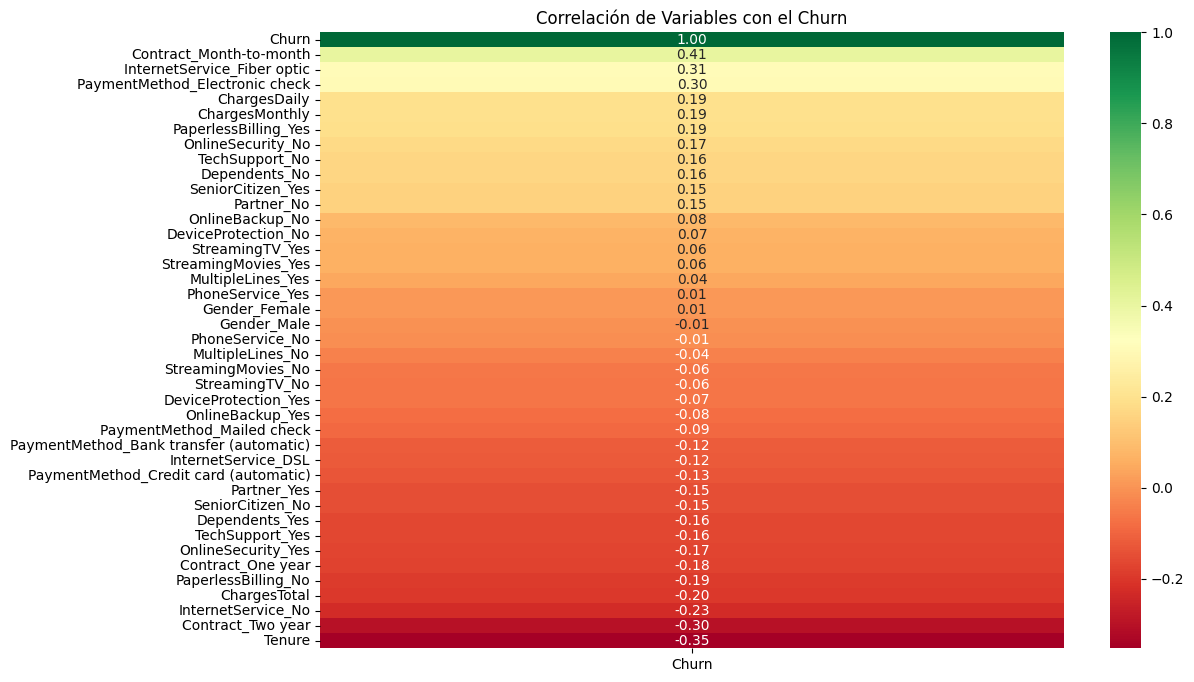

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_correlation_heatmap(df):
    # Seleccionamos solo las variables numéricas y las dummies que creamos
    # para ver cómo se relacionan con 'Churn'
    df_corr = pd.get_dummies(df).corr()

    plt.figure(figsize=(12, 8))
    # Filtramos para ver solo la correlación con Churn para mayor claridad
    churn_corr = df_corr[['Churn']].sort_values(by='Churn', ascending=False)

    sns.heatmap(churn_corr, annot=True, cmap='RdYlGn', fmt=".2f")
    plt.title("Correlación de Variables con el Churn")
    plt.show()

# Ejecución
plot_correlation_heatmap(df_telecom)

analisis del ternuere


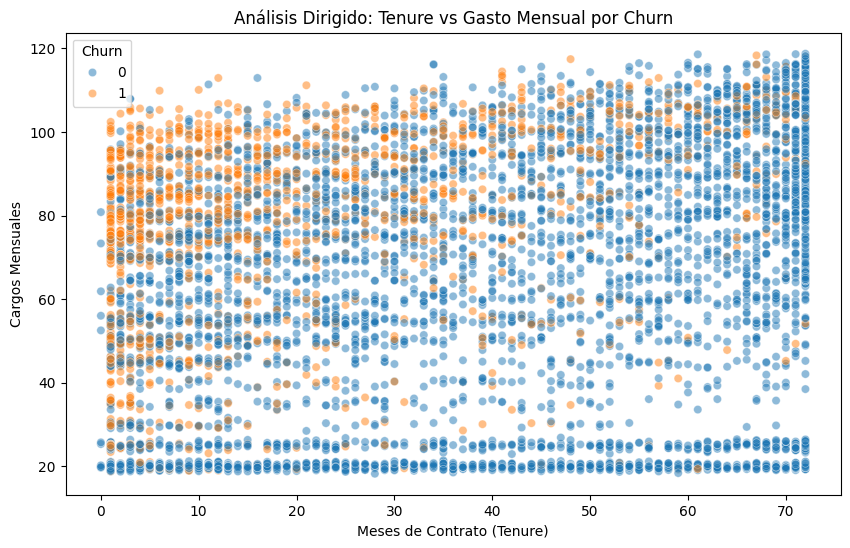

In [ ]:
def plot_scatter_directed(df):
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x='Tenure', y='ChargesMonthly', hue='Churn', data=df, alpha=0.5)
    plt.title('Análisis Dirigido: Tenure vs Gasto Mensual por Churn')
    plt.xlabel('Meses de Contrato (Tenure)')
    plt.ylabel('Cargos Mensuales')
    plt.show()

# Ejecución del análisis adicional
plot_scatter_directed(df_telecom)